# Copula + Kelly: all-at-once vs Nested Clustered Optimization

A two-part lesson. The prequel **`3_copula_model_fitting.ipynb`** examines the 19 assets, fits Student-$t$ marginals and a Gaussian copula on the training set, and saves the fitted model to `copula_model.pkl`. **Run that notebook first** — this one loads its output.

Here we ask whether modeling the dependence properly rescues a naive "optimize all assets at once" approach. It does not. We build **two portfolios on the training set** and test both on the held-out data:

- **All-at-once:** the fitted 19-asset joint model, one large Monte Carlo, full Kelly once.
- **NCO:** cluster the assets by correlation distance, fit a copula and solve Kelly *within* each cluster, then fit a copula and solve Kelly *across* the cluster portfolios.

Both use a single **large, converged** Monte Carlo per optimization — so any out-of-sample gap is genuine model fragility, not sampling noise in the objective. We compare wealth paths and the distribution of realized daily log-growth on the test set.

The standalone, non-copula version of NCO (the original Markowitz's-curse demonstration) is in the appendix notebook `5_appendix_nested_clustered_optimization.ipynb`. *With thanks to Joe Schneider for the original NCO example.*

## Design choices, stated up front

- **Risk-free held out.** The 19 risky assets are modeled; the risk-free asset is treated deterministically as the residual-budget rate $\bar r^f$ (training mean).
- **Student-$t$ marginals + Gaussian copula**, fit in the prequel notebook. Gaussian copula everywhere (within-cluster, across-cluster, all-19): a full 19-dimensional $t$-copula MLE is intractable, and using one family throughout keeps the comparison about *clustering*, not copula family.
- **Full Kelly**, leveraged, risk-free absorbing the residual budget; solved with L-BFGS-B and an analytic gradient.
- **Per-asset $2\times$ historical clip on simulated draws.** Fitted marginals have $\nu\approx 3$ (very fat tails); an un-clipped, converged Kelly integral then sees model-invented catastrophes and refuses all leverage (the optimum collapses toward cash). We clip each asset's *simulated* draws to $[-2L_j, 2L_j]$, $L_j=\max_t|r^{\text{train}}_{t,j}|$ (computed and saved in the prequel). The clip applies **only to simulated draws**; real test returns are used as-is.
- **Single converged Monte Carlo.** $N_{\text{MC}}=500{,}000$ draws per optimization — the all-19 Kelly solution is verified stable to 3 significant figures from 500k→1M draws, so the objective is essentially exact and there is no resampling-noise confound.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os

sns.set(style="whitegrid")
RNG_SEED = 778
N_MC = 500_000
EPS = 1e-9

## Load the fitted model and the data

`copula_model.pkl` is produced by `3_copula_model_fitting.ipynb`. If it is missing, run that notebook first.

In [2]:
if not os.path.exists("copula_model.pkl"):
    raise FileNotFoundError(
        "copula_model.pkl not found. Run 3_copula_model_fitting.ipynb first — "
        "it fits the Student-t marginals and Gaussian copula and saves them here.")

with open("copula_model.pkl", "rb") as fh:
    M = pickle.load(fh)

marginals_all = M["marginals"]      # 19 fitted (df, loc, scale)
chol_all      = M["chol_P"]         # Cholesky of the 19x19 copula correlation
cap_all       = M["cap"]            # per-asset 2x max|train| clip
p             = M["n_assets"]
print(M["note"]); print("loaded keys:", list(M.keys()))

returns = pd.read_csv("vmls_portfolio_returns.csv").to_numpy()
R      = returns[:2000, :19]        # risky training (for clustering + sub-fits)
R_test = returns[2000:, :19]        # risky test
rf_bar = returns[:2000, 19].mean()
T_test = R_test.shape[0]
print(f"R {R.shape}  R_test {R_test.shape}  rf_bar {rf_bar:.3e}/day")

Fitted on training set (first 2000 returns, 19 risky assets) by 3_copula_model_fitting.ipynb
loaded keys: ['asset_names', 'marginals', 'chol_P', 'P_corr', 'cap', 'n_assets', 'note']
R (2000, 19)  R_test (500, 19)  rf_bar 4.000e-05/day


## The Kelly optimizer

With signed weights $w$ and the risk-free asset absorbing the residual budget, $g_t(w)=(1-\sum_j w_j)\bar r^f+\sum_j w_j r_{t,j}$. Full Kelly maximizes expected log growth; we floor the log argument at $\varepsilon$. Excess returns $x_{t,j}=r_{t,j}-\bar r^f$ give a smooth objective with analytic gradient $-\frac1T\sum_t x_t/(1+g_t)$, solved by L-BFGS-B. The *same* routine is used for the all-19 problem and every within/across-cluster solve.

In [3]:
def gross_growth(w, Rm):
    w = np.asarray(w, float)
    return (1.0 - w.sum()) * rf_bar + Rm @ w

def kelly_opt(Rm):
    X = Rm - rf_bar
    base = 1.0 + rf_bar
    def f(w):
        a = np.maximum(base + X @ w, EPS)
        return -np.mean(np.log(a))
    def grad(w):
        a = np.maximum(base + X @ w, EPS)
        return -(X / a[:, None]).mean(axis=0)
    res = minimize(f, np.zeros(Rm.shape[1]), jac=grad,
                   method="L-BFGS-B", options=dict(maxiter=4000))
    return res.x

def mean_log_growth(w, Rm):
    a = np.maximum(1.0 + gross_growth(w, Rm), EPS)
    return np.mean(np.log(a))

## Copula simulation helpers

`fit_gaussian_copula(M)` fits Student-$t$ marginals and the closed-form normal-score correlation for an arbitrary return matrix — used for each **cluster sub-model** and the **across-cluster** model. For the full 19-asset model we instead use the marginals and Cholesky already fitted in the prequel (loaded above), so it is not refit here. `simulate` draws correlated observations and clips each column to its per-column $2\times$ in-sample cap.

In [4]:
def _fit_marginals_and_corr(Mtx):
    k = Mtx.shape[1]
    mar = [stats.t.fit(Mtx[:, j]) for j in range(k)]
    U = np.clip(np.column_stack([stats.t.cdf(Mtx[:, j], *mar[j]) for j in range(k)]),
                1e-6, 1 - 1e-6)
    Z = stats.norm.ppf(U)
    Pc = np.atleast_2d(np.corrcoef(Z, rowvar=False)) if k > 1 else np.array([[1.0]])
    ev, V = np.linalg.eigh(Pc)
    Pc = V @ np.diag(np.clip(ev, 1e-10, None)) @ V.T
    d = np.sqrt(np.diag(Pc))
    Pc = Pc / np.outer(d, d)
    return mar, np.linalg.cholesky(Pc)

def fit_gaussian_copula(Mtx):
    mar, L = _fit_marginals_and_corr(Mtx)
    cap = 2.0 * np.max(np.abs(Mtx), axis=0)
    return dict(mar=mar, L=L, cap=cap, k=Mtx.shape[1])

def simulate(model, n, seed):
    k = model["k"]
    g = np.random.default_rng(seed)
    Zs = g.standard_normal((n, k)) @ model["L"].T
    Us = np.clip(stats.norm.cdf(Zs), 1e-9, 1 - 1e-9)
    sim = np.column_stack([stats.t.ppf(Us[:, j], *model["mar"][j]) for j in range(k)])
    return np.clip(sim, -model["cap"], model["cap"])

## Portfolio B (benchmark) — all 19 assets at once

Simulate one converged Monte Carlo from the **prequel's fitted 19-asset model** (loaded marginals + Cholesky + per-asset cap), then solve full Kelly once.

In [5]:
model_all = dict(mar=marginals_all, L=chol_all, cap=cap_all, k=p)
sim_all = simulate(model_all, N_MC, seed=RNG_SEED)
w_all = kelly_opt(sim_all)

print(f"all-19 Kelly: gross leverage sum|w| = {np.abs(w_all).sum():.2f}")
print(f"            : in-sample (simulated) mean log-growth = {mean_log_growth(w_all, sim_all):.5f}")

all-19 Kelly: gross leverage sum|w| = 16.47
            : in-sample (simulated) mean log-growth = 0.00244


## Portfolio A — Nested Clustered Optimization

### Step 1 — cluster by correlation distance (training)

MLDP correlation distance $D_{ij}=\sqrt{\tfrac12(1-\rho_{ij})}$ on the **training** correlation matrix, then $k$-means with $k=5$ (from-scratch, as in the appendix notebook `5_appendix_nested_clustered_optimization.ipynb`).

In [6]:
def codist(S):
    C = np.corrcoef(S, rowvar=False)
    return np.sqrt(0.5 * (1.0 - C))

def kmeans_(x, k, maxiters=100, tol=1e-5, seed=0):
    g = np.random.default_rng(seed)
    N, d = len(x), len(x[0])
    distances = np.zeros(N)
    assignment = g.integers(1, k + 1, size=N)
    reps = [np.zeros(d) for _ in range(k)]
    Jprev = np.inf
    for it in range(1, maxiters + 1):
        for j in range(1, k + 1):
            grp = np.where(assignment == j)[0]
            if len(grp) > 0:
                reps[j - 1] = np.mean([x[i] for i in grp], axis=0)
        for i in range(N):
            dd = [np.linalg.norm(x[i] - reps[j]) for j in range(k)]
            distances[i] = min(dd)
            assignment[i] = int(np.argmin(dd)) + 1
        J = np.linalg.norm(distances) ** 2 / N
        if it > 1 and abs(J - Jprev) < tol * J:
            break
        Jprev = J
    return assignment

K = 5
D = codist(R)
labels = kmeans_([D[:, i] for i in range(p)], K, seed=RNG_SEED)
print("cluster sizes:", [int((labels == c).sum()) for c in range(1, K + 1)])

cluster sizes: [4, 3, 4, 5, 3]


### Step 2 — within each cluster: fit a copula, one Monte Carlo, Kelly

Each non-empty cluster gets its own Gaussian copula (its assets' training columns), a converged Monte Carlo, and a full-Kelly solve. We keep the within-cluster weights and the cluster portfolio's *in-sample* return series.

In [7]:
within_w = {}
cluster_cols = {}
cluster_train_ret = []

for c in range(1, K + 1):
    idx = np.where(labels == c)[0]
    if len(idx) == 0:
        continue
    mc = fit_gaussian_copula(R[:, idx])
    sim_c = simulate(mc, N_MC, seed=RNG_SEED + c)
    wc = kelly_opt(sim_c)
    within_w[c] = wc
    cluster_cols[c] = idx
    cluster_train_ret.append(R[:, idx] @ wc)

C_train = np.column_stack(cluster_train_ret)
print(f"{C_train.shape[1]} non-empty clusters; within-cluster gross leverage: "
      f"{[round(float(np.abs(within_w[c]).sum()),2) for c in sorted(within_w)]}")

5 non-empty clusters; within-cluster gross leverage: [3.54, 0.9, 2.87, 4.94, 2.34]


### Step 3 — across clusters: fit a copula on the cluster portfolios, one Monte Carlo, Kelly

Treat each cluster portfolio's in-sample return series as one synthetic asset. Fit a Gaussian copula on these series, simulate, solve full Kelly for the across-cluster weights, then **compose**: final weight on asset $j$ in cluster $c$ is (across-weight of $c$) $\times$ (its within-cluster weight).

In [8]:
model_across = fit_gaussian_copula(C_train)
sim_across = simulate(model_across, N_MC, seed=RNG_SEED + 99)
w_across = kelly_opt(sim_across)

w_nco = np.zeros(p)
for a_weight, c in zip(w_across, sorted(within_w)):
    idx = cluster_cols[c]
    w_nco[idx] = a_weight * within_w[c]

print(f"across-cluster weights: {np.round(w_across, 3)}")
print(f"composed NCO portfolio: gross leverage sum|w| = {np.abs(w_nco).sum():.2f}")

across-cluster weights: [ 0.189 -1.113  1.31  -0.08   0.046]
composed NCO portfolio: gross leverage sum|w| = 5.93


## Out-of-sample comparison on the real held-out returns

Both portfolios were built entirely on the training set. We apply their fixed weights to the real 500-day test returns — no clipping, no simulation — and compare.

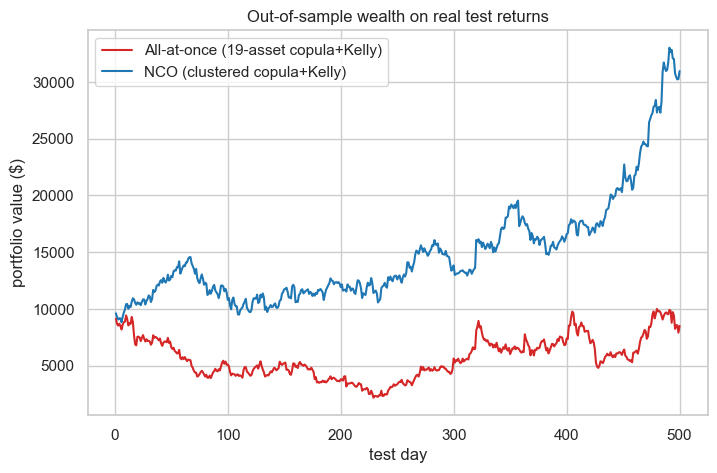

In [9]:
g_all = gross_growth(w_all, R_test)
g_nco = gross_growth(w_nco, R_test)

V_all = 10_000 * np.cumprod(np.maximum(1 + g_all, EPS))
V_nco = 10_000 * np.cumprod(np.maximum(1 + g_nco, EPS))

plt.figure(figsize=(8, 5))
plt.plot(range(1, T_test + 1), V_all, label="All-at-once (19-asset copula+Kelly)",
         color="tab:red")
plt.plot(range(1, T_test + 1), V_nco, label="NCO (clustered copula+Kelly)",
         color="tab:blue")
plt.title("Out-of-sample wealth on real test returns")
plt.xlabel("test day"); plt.ylabel("portfolio value ($)")
plt.legend(loc="upper left"); plt.show()

### Distribution of realized daily log-growth on the test set

The Kelly objective *is* mean log-growth, so the honest out-of-sample score is the realized $\log(1+g_t)$ over the 500 test days. Both histograms with their means (the realized OOS Kelly objective): a higher mean and a less catastrophic left tail is the better portfolio on the criterion it was optimized for.

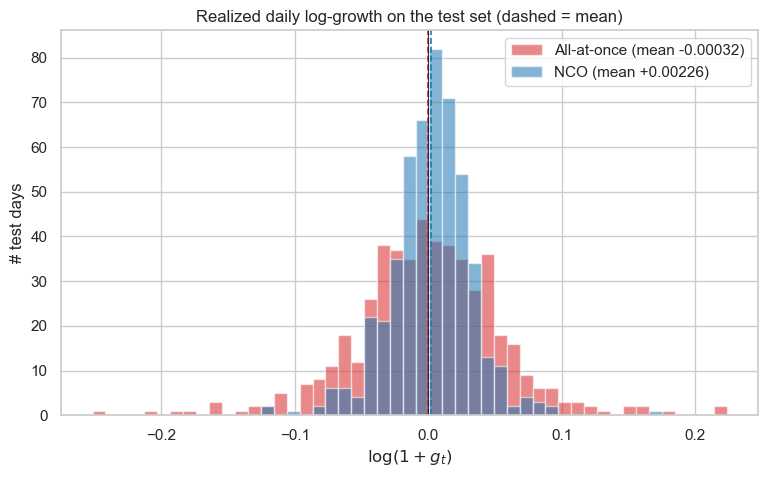

In [10]:
lg_all = np.log(np.maximum(1 + g_all, EPS))
lg_nco = np.log(np.maximum(1 + g_nco, EPS))

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(min(lg_all.min(), lg_nco.min()),
                   max(lg_all.max(), lg_nco.max()), 50)
ax.hist(lg_all, bins=bins, alpha=0.55, color="tab:red",
        label=f"All-at-once (mean {lg_all.mean():+.5f})")
ax.hist(lg_nco, bins=bins, alpha=0.55, color="tab:blue",
        label=f"NCO (mean {lg_nco.mean():+.5f})")
ax.axvline(lg_all.mean(), color="tab:red", ls="--", lw=1.2)
ax.axvline(lg_nco.mean(), color="tab:blue", ls="--", lw=1.2)
ax.axvline(0, color="k", lw=.6)
ax.set_title("Realized daily log-growth on the test set (dashed = mean)")
ax.set_xlabel(r"$\log(1+g_t)$"); ax.set_ylabel("# test days")
ax.legend(); plt.show()

In [11]:
summary = pd.DataFrame({
    "gross leverage sum|w|": [np.abs(w_all).sum(), np.abs(w_nco).sum()],
    "OOS final wealth ($)":  [V_all[-1], V_nco[-1]],
    "OOS total return":      [V_all[-1] / 10_000 - 1, V_nco[-1] / 10_000 - 1],
    "mean daily log-growth": [lg_all.mean(), lg_nco.mean()],
    "worst daily log-growth":[lg_all.min(), lg_nco.min()],
}, index=["All-at-once", "NCO"])
summary.style.format({"gross leverage sum|w|": "{:.2f}",
                      "OOS final wealth ($)": "{:,.2f}",
                      "OOS total return": "{:.2%}",
                      "mean daily log-growth": "{:+.5f}",
                      "worst daily log-growth": "{:+.5f}"})

,gross leverage sum|w|,OOS final wealth ($),OOS total return,mean daily log-growth,worst daily log-growth
All-at-once,16.47,"8,501.55",-14.98%,-0.00032,-0.25149
NCO,5.93,"30,947.02",209.47%,+0.00226,-0.12282


## Synthesis

Both portfolios used a *fully converged* Kelly integral (500k draws, verified stable), the *same* marginals, the *same* copula family, the *same* per-asset clip, and the *same* optimizer. The only difference is **structure**: the all-at-once model inverts one 19-asset dependence object; NCO never does — it clusters by correlation distance and solves small, well-conditioned within- and across-cluster problems whose errors stay local.

The out-of-sample wealth path and the realized daily log-growth distribution show the consequence. Modeling the dependence with a copula does **not** by itself rescue the all-at-once approach: the fragility is in optimizing the full cross-asset object, and the nested structure is what addresses it. This is the copula-model analogue of the Markowitz's-curse demonstration in the appendix notebook `5_appendix_nested_clustered_optimization.ipynb`.

**Sequel (discussed, not coded here):** cross-validation with *purging and embargo*, the natural next refinement when observations overlap in time.